In [5]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import numpy as np

In [57]:
dfGDP = pd.read_csv("dfCOG.csv", usecols= ["country_gdp", "ed_percent_gdp"])
dfGDP.head()


,country_gdp,ed_percent_gdp
0,29536.6780,4.730330
1,6225.5327,2.951152
2,55781.7000,4.139572
3,29105.1020,4.999240
4,NaN,4.615470


In [61]:
dfGDP["country_gdp"] = np.log(dfGDP["country_gdp"])
dfGDP.rename(columns ={"country_gdp" : "ln_country_gdp"}, inplace=True)
dfGDP.head()

,ln_country_gdp,ed_percent_gdp
0,2.331502,4.730330
1,2.167500,2.951152
2,2.391438,4.139572
3,2.330071,4.999240
4,NaN,4.615470


In [35]:
country_codes = pd.read_csv("dfCOG.csv", usecols= ["CNTRYID"])
country_codes.head()

,CNTRYID
0,100
1,116
2,124
3,152
4,158


In [63]:
mean_GDP = dfGDP.mean()
sd_GDP = dfGDP.std()

In [65]:
dfGDP[["Normalized_ln_GDP", "Normalized_Ed_Percent_GDP"]] = (dfGDP - mean_GDP)/sd_GDP

In [67]:
dfGDP.head()

,ln_country_gdp,ed_percent_gdp,Normalized_ln_GDP,Normalized_Ed_Percent_GDP
0,2.331502,4.730330,-0.081195,0.190766
1,2.167500,2.951152,-2.380421,-1.350023
2,2.391438,4.139572,0.759085,-0.320838
3,2.330071,4.999240,-0.101257,0.423646
4,NaN,4.615470,NaN,0.091296


In [69]:
dfGDP = pd.concat([country_codes, dfGDP], axis=1)
dfGDP.head()

,CNTRYID,ln_country_gdp,ed_percent_gdp,Normalized_ln_GDP,Normalized_Ed_Percent_GDP
0,100,2.331502,4.730330,-0.081195,0.190766
1,116,2.167500,2.951152,-2.380421,-1.350023
2,124,2.391438,4.139572,0.759085,-0.320838
3,152,2.330071,4.999240,-0.101257,0.423646
4,158,NaN,4.615470,NaN,0.091296


In [39]:
dfGDP.to_csv("GDP_Normalized_Data.csv")

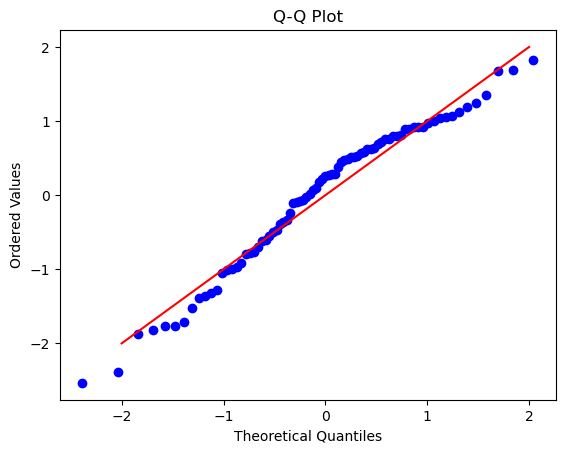

In [71]:
stats.probplot(dfGDP["Normalized_ln_GDP"], dist="norm", plot=plt)
ax = plt.gca()
xlim = [-2, 2]
ylim = [-2, 2]
ax.plot(xlim, ylim, color = "red", linestyle="-", clip_on=True, scalex=False, scaley=False)
plt.title('Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()

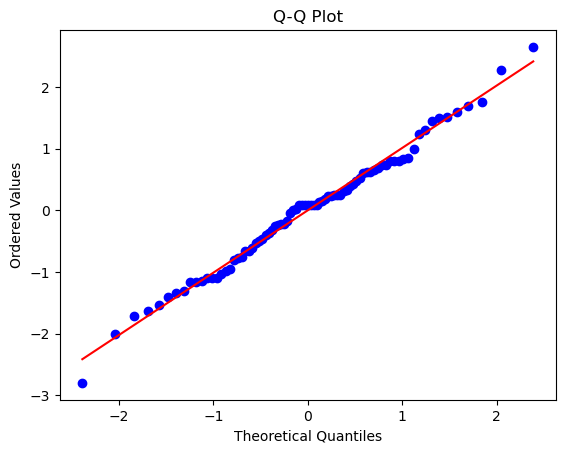

In [75]:
stats.probplot(dfGDP["Normalized_Ed_Percent_GDP"], dist="norm", plot=plt)
plt.title('Q-Q Plot')
plt.xlabel('Theoretical Quantiles')
plt.ylabel('Ordered Values')
plt.show()